# Customer-Level Analytics

## Objective

This notebook answers the central question of the customer analytics phase: 
**who are our customers, and how should we treat them differently?**

Using transaction-level data from the cleaned Online Retail II dataset, this analysis:
1. Builds RFM (Recency, Frequency, Monetary) and supporting behavioral features 
   for every identified customer
2. Segments customers into distinct groups using K-Means clustering, validated 
   against Hierarchical Clustering
3. Profiles each segment's purchasing behavior, revenue contribution, and 
   product preferences
4. Translates each segment into a concrete business strategy — who should 
   receive loyalty rewards, who needs a retention campaign, and who is a low 
   marketing priority

**Scope:** This analysis uses only identified, non-cancelled, product-level 
transactions (`customer_df`) — guest checkouts (14.8% of revenue) are excluded, 
since segmentation requires a persistent customer identity to track behavior 
over time. Wholesale-scale outlier customers, identified during Global EDA, are 
handled implicitly through percentile-rank normalization rather than removed, 
since this bounds their influence on clustering without discarding real 
customers from the analysis.

**Business questions this phase answers:**
- Which customers are most valuable?
- Which customers are at risk of churning?
- Which customers should receive discounts or loyalty rewards?
- How should marketing and retention efforts be prioritized across the customer base?

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_parquet('data/cleaned_data.parquet', engine='pyarrow')
df['InvoiceMonth'] = df['InvoiceDateTime'].dt.to_period('M')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1027838 entries, 0 to 1027837
Data columns (total 17 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   Invoice           1027838 non-null  str           
 1   StockCode         1027838 non-null  str           
 2   Description       1027838 non-null  str           
 3   Quantity          1027838 non-null  int64         
 4   InvoiceDate       1027838 non-null  object        
 5   Price             1027838 non-null  float64       
 6   CustomerID        1027838 non-null  str           
 7   Country           1027838 non-null  str           
 8   InvoiceDateTime   1027838 non-null  datetime64[us]
 9   InvoiceTime       1027838 non-null  object        
 10  InvoiceHour       1027838 non-null  int32         
 11  InvoiceDayOfWeek  1027838 non-null  str           
 12  is_guest          1027838 non-null  bool          
 13  is_cancellation   1027838 non-null  bool          
 1

In [4]:
customer_df = df[
    (~df['is_cancellation']) &
    (~df['is_non_product']) &
    (~df['is_guest'])
].copy()

In [5]:
customer_df['CustomerID'].nunique()

5853

## Customer Segmentation

We will calculate the following columns to be used for customer segmentation. 
- Recency
- Frequency
- Monetary
- Tenure (days since first purchase)
- Average order value
- Unique products purchased (proxy for diversity/breadth)

### RFM Analysis

RFM stands for Recency, Frequency, and Monetary Value. It is a marketing model used to analyze and group customers based on their past buying behavior. Businesses use it to find their best or most loyal buyers.  

The Three Core Metrics:  
**Recency (R):** How long ago the customer made their last purchase. Fresh buyers get a high score because they remember the brand.  
**Frequency (F):** How often the customer buys things in a set time. Higher numbers mean more loyal shoppers.  
**Monetary Value (M):** How much money the customer spends overall. Bigger spenders get a high score.  

Recency:
- It is calculated by subtracting each customer's most recent InvoiceDate from a fixed reference date.
- In our case, we will use this reference date as one day after the last date (9th Dec 2011) in the dataset, which is 10/12/2011.

In [6]:
from datetime import timedelta, date

recency_df = customer_df.groupby(['CustomerID'], as_index=False)['InvoiceDate'].max()
recency_df.columns = ['CustomerID', 'LastPurchaseDate']
recent_date = recency_df['LastPurchaseDate'].max() + timedelta(days=1)
recency_df['Recency'] = recency_df['LastPurchaseDate'].apply(lambda x: (recent_date - x).days)
recency_df.head()

,CustomerID,LastPurchaseDate,Recency
0,12346,2011-01-18,326
1,12347,2011-12-07,3
2,12348,2011-09-25,76
3,12349,2011-11-21,19
4,12350,2011-02-02,311


In [7]:
# Frequency - Total number of times a customer has purchased in the given window 
frequency_df = customer_df.groupby(['CustomerID'], as_index=False)['Invoice'].nunique()
frequency_df.columns = ['CustomerID', 'Frequency']
frequency_df.head()

,CustomerID,Frequency
0,12346,3
1,12347,8
2,12348,5
3,12349,3
4,12350,1


In [8]:
# Monetary - Total amount spent by a customer in the given window
monetary_df = customer_df.groupby(['CustomerID'], as_index=False)['Revenue'].sum()
monetary_df.columns = ['CustomerID', 'Monetary']
monetary_df.head()

,CustomerID,Monetary
0,12346,77352.96
1,12347,4921.53
2,12348,1658.40
3,12349,3678.69
4,12350,294.40


In [9]:
# Merge all three
rf_df = recency_df.merge(frequency_df, on='CustomerID')
rfm_df = rf_df.merge(monetary_df, on='CustomerID').drop(['LastPurchaseDate'], axis=1)
rfm_df.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,3,77352.96
1,12347,3,8,4921.53
2,12348,76,5,1658.40
3,12349,19,3,3678.69
4,12350,311,1,294.40


In [10]:
rfm_df.describe()

,Recency,Frequency,Monetary
count,5853.000000,5853.000000,5853.000000
mean,200.700666,6.252691,2916.210958
std,208.519603,12.750278,14305.694223
min,1.000000,1.000000,0.000000
25%,26.000000,1.000000,339.500000
50%,96.000000,3.000000,856.010000
75%,380.000000,7.000000,2240.900000
max,739.000000,373.000000,580987.040000


- It can be seen that the values vary drastically. The range is large and there are a few outliers. Hence we will go for rank normalization.
- Percentile rank normalization inherently compresses extreme values.
- A customer with extremely high monetary value and another with somewhat lower but still top-percentile monetary value receive similar rank scores, reducing the influence of extreme magnitudes.
- This is functionally similar to what a log-transform does for skew, but even more robust, since it's bounded to a fixed 0-100 range no matter how extreme the tail is.
- This also addresses the wholesale-scale outlier customers identified in Global EDA — since rank normalization bounds every feature to a fixed 0-100 range, extreme-value customers can no longer dominate the K-means distance calculation the way raw £/day-count values would.

In [11]:
# Find the rank for all three
rfm_df['R_rank'] = rfm_df['Recency'].rank(ascending=False)
rfm_df['F_rank'] = rfm_df['Frequency'].rank(ascending=True)
rfm_df['M_rank'] = rfm_df['Monetary'].rank(ascending=True)

In [12]:
# Normalize the ranks
rfm_df['R_rank_norm'] = (rfm_df['R_rank'] / rfm_df['R_rank'].max()) * 100
rfm_df['F_rank_norm'] = (rfm_df['F_rank'] / rfm_df['F_rank'].max()) * 100
rfm_df['M_rank_norm'] = (rfm_df['M_rank'] / rfm_df['M_rank'].max()) * 100

In [13]:
rfm_df.drop(columns=['R_rank', 'F_rank', 'M_rank'], inplace=True)
rfm_df.head()

,CustomerID,Recency,Frequency,Monetary,R_rank_norm,F_rank_norm,M_rank_norm
0,12346,326,3,77352.96,28.812543,49.444729,99.692465
1,12347,3,8,4921.53,97.172721,79.446438,89.185033
2,12348,76,5,1658.40,54.180946,66.461644,67.862635
3,12349,19,3,3678.69,80.954421,49.444729,84.606185
4,12350,311,1,294.40,29.943454,13.839057,20.707330


### Tenure

It can be defined as the total period a customer has been purchasing at the company.  
We will calculate it as the time period between the first purchase in our dataset to the last date of the dataset.

In [14]:
tenure_df = customer_df.groupby(['CustomerID'], as_index=False)['InvoiceDate'].min()
tenure_df.columns = ['CustomerID', 'FirstPurchaseDate']
recent_date = customer_df['InvoiceDate'].max() + timedelta(days=1)
tenure_df['Tenure'] = tenure_df['FirstPurchaseDate'].apply(lambda x: (recent_date-x).days)
tenure_df['Tenure_rank'] = tenure_df['Tenure'].rank(ascending=True)
tenure_df['Tenure_rank_norm'] = (tenure_df['Tenure_rank'] / tenure_df['Tenure_rank'].max()) * 100
tenure_df.drop(['FirstPurchaseDate', 'Tenure_rank'], axis=1, inplace=True)
segmentation_df = rfm_df.merge(tenure_df, on='CustomerID')
segmentation_df.head()

,CustomerID,Recency,Frequency,Monetary,R_rank_norm,F_rank_norm,M_rank_norm,Tenure,Tenure_rank_norm
0,12346,326,3,77352.96,28.812543,49.444729,99.692465,648,71.174040
1,12347,3,8,4921.53,97.172721,79.446438,89.185033,405,33.491134
2,12348,76,5,1658.40,54.180946,66.461644,67.862635,439,40.850405
3,12349,19,3,3678.69,80.954421,49.444729,84.606185,590,59.235669
4,12350,311,1,294.40,29.943454,13.839057,20.707330,311,25.038733


### Average Order Value

AOV is the average amount of money a customer spends ot a time.

In [15]:
order_revenue = customer_df.groupby(['CustomerID', 'Invoice'], as_index=False)['Revenue'].sum()
avg_df = order_revenue.groupby('CustomerID', as_index=False)['Revenue'].mean()
avg_df.columns = ['CustomerID', 'AvgOrderValue']
avg_df['AOV_rank'] = avg_df['AvgOrderValue'].rank(ascending=True)
avg_df['AOV_rank_norm'] = (avg_df['AOV_rank'] / avg_df['AOV_rank'].max()) * 100
segmentation_df = segmentation_df.merge(avg_df, on='CustomerID').drop('AOV_rank', axis=1)
segmentation_df.head()

,CustomerID,Recency,Frequency,Monetary,R_rank_norm,F_rank_norm,M_rank_norm,Tenure,Tenure_rank_norm,AvgOrderValue,AOV_rank_norm
0,12346,326,3,77352.96,28.812543,49.444729,99.692465,648,71.174040,25784.32000,99.982915
1,12347,3,8,4921.53,97.172721,79.446438,89.185033,405,33.491134,615.19125,89.663420
2,12348,76,5,1658.40,54.180946,66.461644,67.862635,439,40.850405,331.68000,62.224500
3,12349,19,3,3678.69,80.954421,49.444729,84.606185,590,59.235669,1226.23000,97.932684
4,12350,311,1,294.40,29.943454,13.839057,20.707330,311,25.038733,294.40000,53.340167


### Unique Products Purchased

We will also calculate the total number of unique products purchased by customers throughout the dataset.  
This helps us understand the product diversity in our dataset.

In [16]:
unique_df = customer_df.groupby(['CustomerID'], as_index=False)['StockCode'].nunique()
unique_df.columns = ['CustomerID', 'Diversity']
unique_df['Diversity_rank'] = unique_df['Diversity'].rank(ascending=True)
unique_df['Diversity_rank_norm'] = (unique_df['Diversity_rank'] / unique_df['Diversity_rank'].max()) * 100
segmentation_df = segmentation_df.merge(unique_df, on='CustomerID').drop('Diversity_rank', axis=1)
segmentation_df.head()

,CustomerID,Recency,Frequency,Monetary,R_rank_norm,F_rank_norm,M_rank_norm,Tenure,Tenure_rank_norm,AvgOrderValue,AOV_rank_norm,Diversity,Diversity_rank_norm
0,12346,326,3,77352.96,28.812543,49.444729,99.692465,648,71.174040,25784.32000,99.982915,25,32.325303
1,12347,3,8,4921.53,97.172721,79.446438,89.185033,405,33.491134,615.19125,89.663420,126,80.522809
2,12348,76,5,1658.40,54.180946,66.461644,67.862635,439,40.850405,331.68000,62.224500,24,31.163506
3,12349,19,3,3678.69,80.954421,49.444729,84.606185,590,59.235669,1226.23000,97.932684,137,82.419272
4,12350,311,1,294.40,29.943454,13.839057,20.707330,311,25.038733,294.40000,53.340167,16,21.168631


### Clustering

The rank-normalized features are continuous and on a common 0–100 scale, making distance-based clustering such as K-Means appropriate for this analysis.

In [17]:
segmentation_df.dtypes

CustomerID                 str
Recency                  int64
Frequency                int64
Monetary               float64
R_rank_norm            float64
F_rank_norm            float64
M_rank_norm            float64
Tenure                   int64
Tenure_rank_norm       float64
AvgOrderValue          float64
AOV_rank_norm          float64
Diversity                int64
Diversity_rank_norm    float64
dtype: object

In [18]:
from sklearn.cluster import KMeans

# We will only use the normalized features for clustering
clustering_features = ['R_rank_norm', 'F_rank_norm', 'M_rank_norm','Tenure_rank_norm', 'AOV_rank_norm', 'Diversity_rank_norm']

X = segmentation_df[clustering_features]

# Try a few different number of clusters
scores = []
for i in range(2, 7):
    kmeans = KMeans(n_clusters=i, max_iter=40, random_state=42, verbose=False).fit(X)
    scores.append(kmeans.inertia_)

print(len(scores))

5


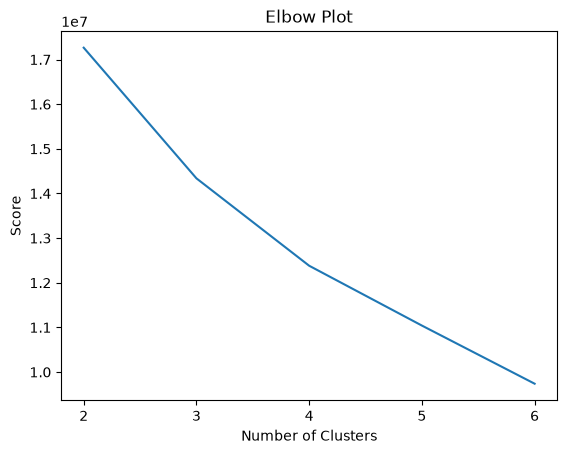

In [19]:
# Plot the elbow curve
import matplotlib.pyplot as plt

plt.plot(range(2, 7, 1), scores)
plt.xticks(ticks=range(2,7))
plt.xlabel("Number of Clusters")
plt.ylabel("Score")
plt.title("Elbow Plot")
plt.show()

In [20]:
# Calculate the silhoutte scores
from sklearn.metrics import silhouette_score

for i in range(2, 7):
    kmeans = KMeans(n_clusters=i, max_iter=40, random_state=42, verbose=False).fit(X)
    cluster_labels = kmeans.labels_
    silhouette_avg = silhouette_score(X, cluster_labels)
    print(f"For cluster {i}, the silhoutte score is {silhouette_avg}")

For cluster 2, the silhoutte score is 0.3435553107445041
For cluster 3, the silhoutte score is 0.2729754879796921
For cluster 4, the silhoutte score is 0.25881070239209825
For cluster 5, the silhoutte score is 0.24757494313542686
For cluster 6, the silhoutte score is 0.24360413991409924


- We can see there are two slight inflections or elbows at 3 and 4.
- The silhoutte score is best for 2 clusters. But selecting 2 clusters will not be helpful from a business perspective.
- Selecting either 3 or 4 seems like a better choice. We could try to run the algorithm for both and check the clusters.

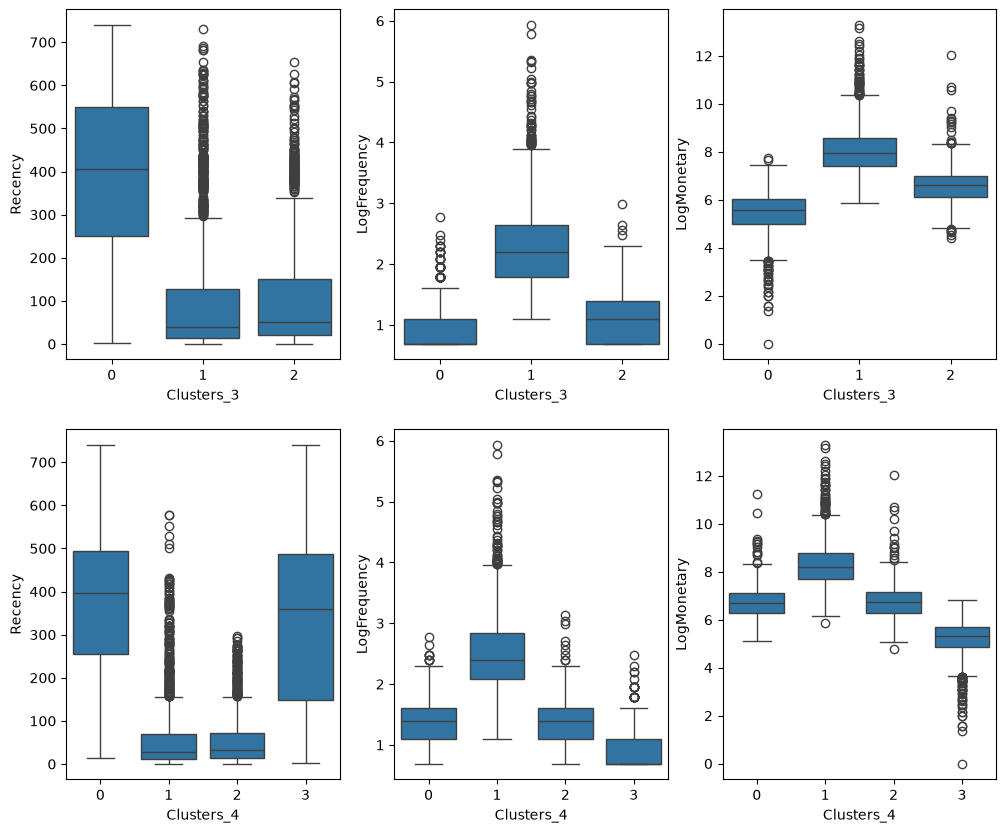

In [21]:
import seaborn as sns

trials = [3, 4]

segmentation_df['LogMonetary'] = np.log1p(segmentation_df['Monetary'])
segmentation_df['LogFrequency'] = np.log1p(segmentation_df['Frequency'])

fig, axes = plt.subplots(2, 3, figsize=(12, 10))

for i, j in enumerate(trials):
    kmeans = KMeans(n_clusters=j, max_iter=40, random_state=42, verbose=False).fit(X)
    clusters = kmeans.labels_
    segmentation_df[f'Clusters_{j}'] = clusters
    sns.boxplot(x=f'Clusters_{j}', y='Recency', data=segmentation_df, ax=axes[i, 0])
    sns.boxplot(x=f'Clusters_{j}', y='LogFrequency', data=segmentation_df, ax=axes[i, 1])
    sns.boxplot(x=f'Clusters_{j}', y='LogMonetary', data=segmentation_df, ax=axes[i, 2])
    
plt.show()

There seems to be a distinct separation between clusters in both cases.  
We can check the mean/median for actual values of our columns - Recency, Monetary, Frequency, etc.

In [22]:
segmentation_df.groupby('Clusters_3')[['Recency','Frequency','Monetary','AvgOrderValue','Tenure','Diversity']].agg(['mean','median','count'])

Recency               Frequency                  Monetary  \
                  mean median count       mean median count         mean   
Clusters_3                                                                 
0           394.979824  407.0  1933   1.785825    1.0  1933   318.586540   
1           102.672196   40.0  2291  12.682235    8.0  2291  6413.308308   
2           108.031308   51.0  1629   2.510743    2.0  1629  1080.334944   

                          AvgOrderValue                        Tenure         \
             median count          mean      median count        mean median   
Clusters_3                                                                     
0            258.55  1933    195.183672  164.530000  1933  484.491981  520.0   
1           2855.32  2291    454.561257  340.443750  2291  625.336971  664.0   
2            737.05  1629    510.004023  331.526667  1629  250.371393  237.0   

                   Diversity               
           count        mean median count  
Clusters_3                                 
0           1933   20.786342   16.0  1933  
1           2291  158.519860  119.0  2291  
2           1629   47.665439   38.0  1629

In [23]:
segmentation_df.groupby('Clusters_4')[['Recency','Frequency','Monetary','AvgOrderValue','Tenure','Diversity']].agg(['mean','median','count'])

Recency               Frequency                  Monetary  \
                  mean median count       mean median count         mean   
Clusters_4                                                                 
0           386.994413  396.0  1253   2.986433    3.0  1253  1116.410370   
1            59.196123   29.0  1754  15.100912   10.0  1754  7786.554676   
2            54.083721   33.0  1290   3.072868    3.0  1290  1289.696792   
3           331.747429  360.0  1556   1.544987    1.0  1556   223.904100   

                          AvgOrderValue                        Tenure         \
             median count          mean      median count        mean median   
Clusters_4                                                                     
0            818.79  1253    450.648262  320.964286  1253  597.891460  622.0   
1           3589.62  1754    452.292671  348.589013  1754  636.773660  674.0   
2            828.32  1290    500.240525  326.635000  1290  227.664341  211.5   
3            199.95  1556    158.221426  146.350000  1556  396.708869  414.0   

                   Diversity               
           count        mean median count  
Clusters_4                                 
0           1253   49.272147   41.0  1253  
1           1754  182.652794  141.0  1754  
2           1290   57.793023   44.0  1290  
3           1556   15.637532   12.0  1556

- We can see that difference between mean and median is much larger in case of 3 clusters. 
- When a cluster's mean is more than double its median, that's a strong sign the cluster is blending two different behavioral groups — some genuinely recent customers and some meaningfully lapsed ones, averaged together into one bucket that doesn't represent either group well.
- Compare that to K=4, where every cluster's mean and median sit much closer together (e.g., Cluster 1 — still some spread, but nowhere near the K=3 distortion) — a sign of tighter, more internally consistent groups.

Using 4 clusters seems to be a better choice after comparison. We can perform a sanity-check by comparing our findings with Hierarchical Clustering.

col_0,0,1,2,3
row_0,,,,
0,454,600,199,0
1,1749,3,2,0
2,362,123,776,29
3,0,697,149,710


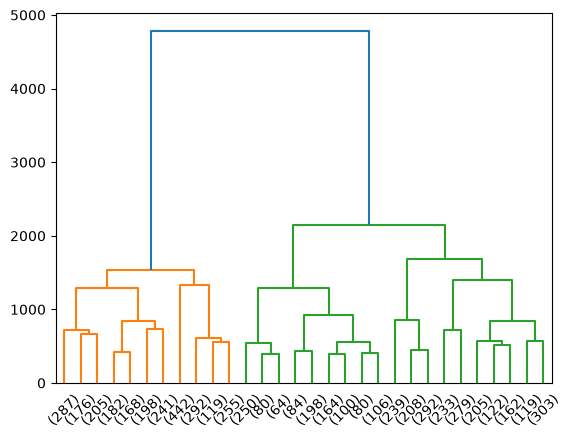

In [24]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# Quick dendrogram for visual sanity check
Z = linkage(X, method='ward')
dendrogram(Z, truncate_mode='lastp', p=30)

# Compare cluster assignment agreement with K-means
hier = AgglomerativeClustering(n_clusters=4, linkage='ward')
hier_labels = hier.fit_predict(X)

# K-means
kmeans_4 = KMeans(n_clusters=4, max_iter=40, random_state=42).fit(X)
clusters = kmeans_4.labels_

# Cross-tab against your K-means labels to see how much they agree
pd.crosstab(clusters, hier_labels)

- row_0 = your K-means cluster labels (0-3), col_0 = your hierarchical cluster labels (0-3). 
Each cell is "how many customers got K-means label X and hierarchical label Y."
- This is checking agreement, not accuracy — there's no ground truth here, just whether two different methods independently landed on similar groupings.

**Note:** Cluster numbers are arbitrary and don't correspond across methods. K-means cluster "0" has no inherent relationship to hierarchical cluster "0" — they're just labels each algorithm assigned independently. So you read this by looking for each row's dominant column (largest value), not by matching same-numbered labels.

The grouping seems largely consistent in both clustering algorithms.

In [25]:
segmentation_df = segmentation_df.drop(['Clusters_3', 'Clusters_4'], axis=1)

**Final K-Means Clustering**

In [26]:
clustering_features = ['R_rank_norm', 'F_rank_norm', 'M_rank_norm','Tenure_rank_norm', 'AOV_rank_norm', 'Diversity_rank_norm']

X = segmentation_df[clustering_features]

kmeans = KMeans(n_clusters=4, max_iter=40, random_state=42, verbose=False).fit(X)
clusters = kmeans.labels_
segmentation_df['Cluster'] = clusters

In [27]:
segmentation_df.head()

,CustomerID,Recency,Frequency,Monetary,R_rank_norm,F_rank_norm,M_rank_norm,Tenure,Tenure_rank_norm,AvgOrderValue,AOV_rank_norm,Diversity,Diversity_rank_norm,LogMonetary,LogFrequency,Cluster
0,12346,326,3,77352.96,28.812543,49.444729,99.692465,648,71.174040,25784.32000,99.982915,25,32.325303,11.256147,1.386294,0
1,12347,3,8,4921.53,97.172721,79.446438,89.185033,405,33.491134,615.19125,89.663420,126,80.522809,8.501578,2.197225,1
2,12348,76,5,1658.40,54.180946,66.461644,67.862635,439,40.850405,331.68000,62.224500,24,31.163506,7.414211,1.791759,2
3,12349,19,3,3678.69,80.954421,49.444729,84.606185,590,59.235669,1226.23000,97.932684,137,82.419272,8.210584,1.386294,1
4,12350,311,1,294.40,29.943454,13.839057,20.707330,311,25.038733,294.40000,53.340167,16,21.168631,5.688330,0.693147,3


So now, each customer has their own cluster. To understand the customers in each cluster, we will make a few plots and then assign a name to each cluster.  
These can then be used to shape the marketing strategies.

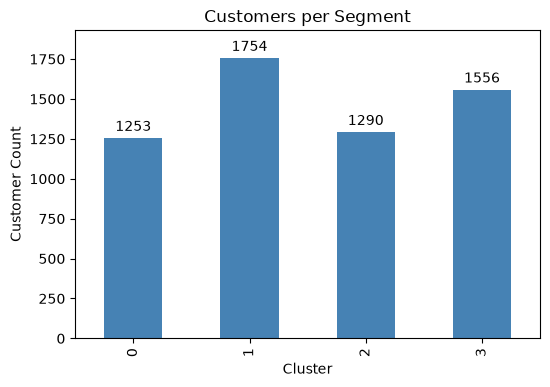

In [28]:
# Cluster size — headcount per segment
cluster_sizes = segmentation_df['Cluster'].value_counts().sort_index()
plt.figure(figsize=(6, 4))

ax = cluster_sizes.plot(kind='bar', color='steelblue')
ax.bar_label(ax.containers[0], padding=3)
plt.title('Customers per Segment')
plt.xlabel('Cluster')
plt.ylabel('Customer Count')
plt.ylim(0, cluster_sizes.max() * 1.1)
plt.show()

Cluster 1 is our largest cluster, followed by cluster 3.  
Clusters 0 and 2 have similar number of customers.

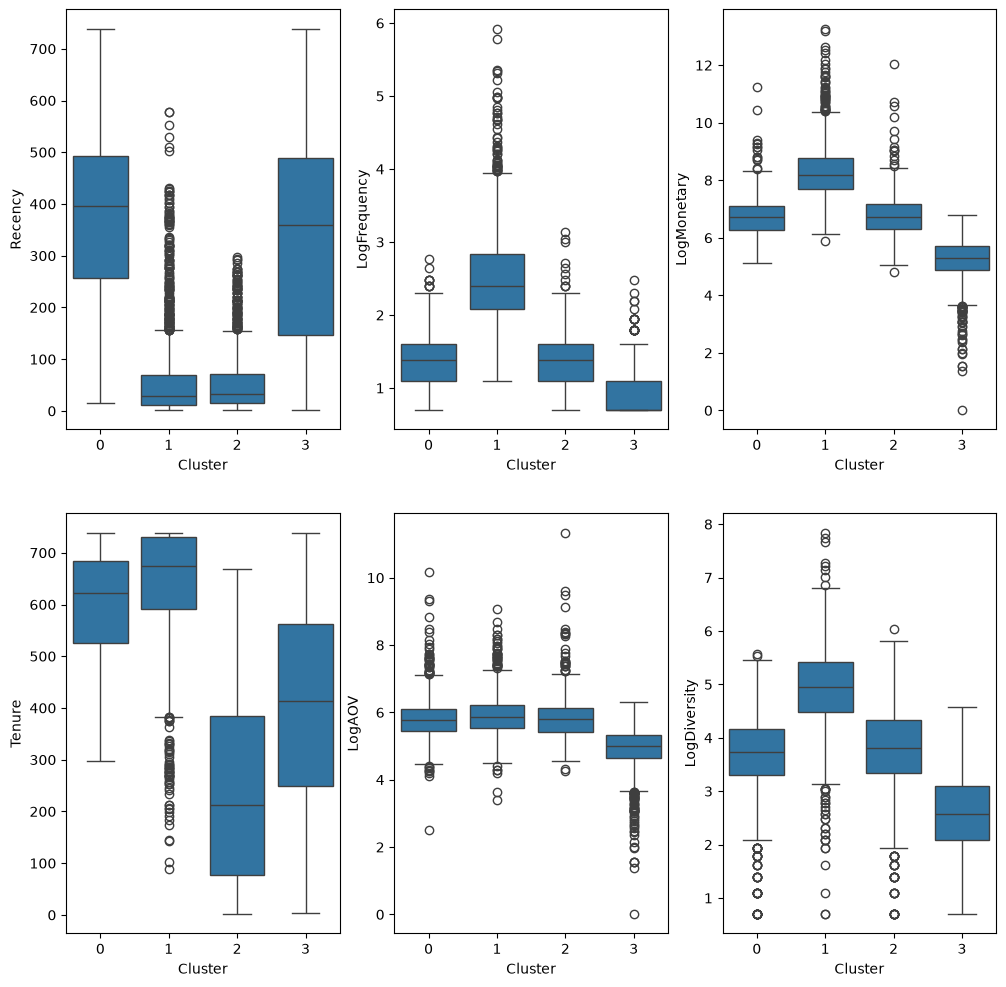

In [29]:
# Box Plots to see how the features vary

import seaborn as sns

segmentation_df['LogAOV'] = np.log1p(segmentation_df['AvgOrderValue'])
segmentation_df['LogDiversity'] = np.log1p(segmentation_df['Diversity'])

fig, axes = plt.subplots(2, 3, figsize=(12, 12))

sns.boxplot(x='Cluster', y='Recency', data=segmentation_df, ax=axes[0, 0])
sns.boxplot(x='Cluster', y='LogFrequency', data=segmentation_df, ax=axes[0, 1])
sns.boxplot(x='Cluster', y='LogMonetary', data=segmentation_df, ax=axes[0, 2])
sns.boxplot(x='Cluster', y='Tenure', data=segmentation_df, ax=axes[1, 0])
sns.boxplot(x='Cluster', y='LogAOV', data=segmentation_df, ax=axes[1, 1])
sns.boxplot(x='Cluster', y='LogDiversity', data=segmentation_df, ax=axes[1, 2])
    
plt.show()

- Cluster 1 - Very low Recency (~30 days), highest Frequency, highest Monetary, highest Tenure, and highest Product Diversity.
- Cluster 0 - High Recency (~400 days), low Frequency, moderate-to-high Monetary, high Tenure (~600+ days), moderate AOV, and moderate Product Diversity.
- Cluster 2 - Very low Recency (<50 days), low Frequency, moderate-to-high Monetary, lowest Tenure (<200 days), moderate AOV, and moderate Product Diversity.
- Cluster 3 - High Recency (~350–400+ days), low Frequency, lowest Monetary, moderate Tenure, lowest AOV, and lowest Product Diversity.

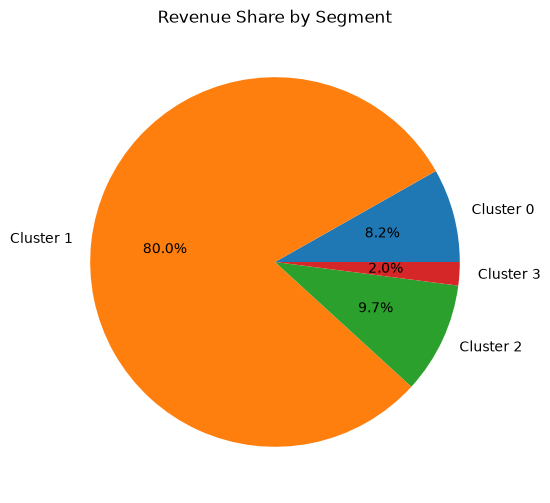

In [30]:
# Revenue share per segment
rev_share = segmentation_df.groupby('Cluster')['Monetary'].sum()
plt.figure(figsize=(6,6))
plt.pie(rev_share, labels=[f'Cluster {i}' for i in rev_share.index], autopct='%1.1f%%')
plt.title('Revenue Share by Segment')
plt.show()

- Cluster 1 clearly has the highest revenue at 80%. (Pareto principle)
- Cluter 0 and Cluster 2 have a similar share at 8.2% and 9.7%.
- Cluster 3 has the lowest share of revenue at 2.0%.  

This confirms our finding from the previous box plots.

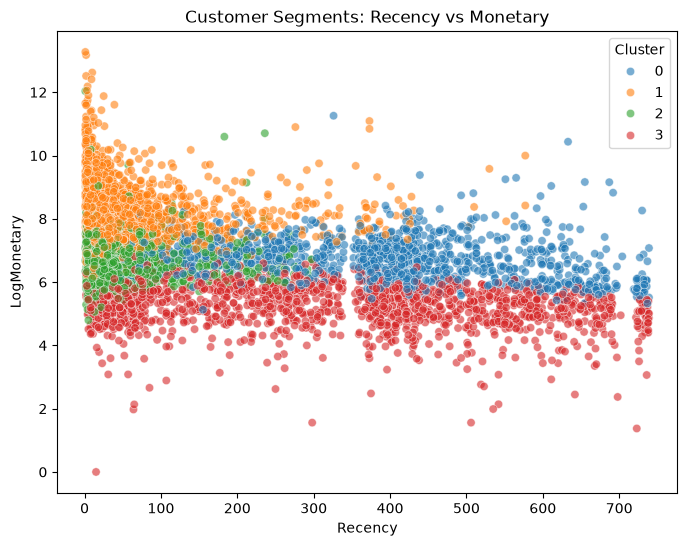

In [31]:
# Recency vs Monetary scatter, colored by cluster
plt.figure(figsize=(8,6))
sns.scatterplot(data=segmentation_df, x='Recency', y='LogMonetary', hue='Cluster', palette='tab10', alpha=0.6)
plt.title('Customer Segments: Recency vs Monetary')
plt.show()

- Cluster 1 - Low Recency, High Monetary - Top Left.
- Cluster 0 - High Recency, Medium to High Spend.
- Cluster 2 - Low Recency, Medium Spend.
- Cluster 3 - Varying Recency, Lowest Spend.

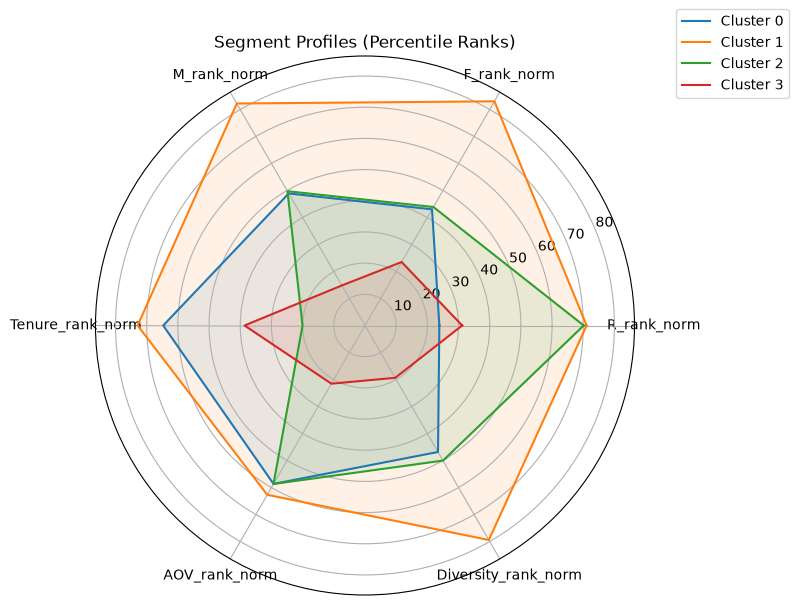

In [32]:
# Radar/spider chart — compact multi-dimensional segment comparison
from math import pi
radar_features = ['R_rank_norm','F_rank_norm','M_rank_norm','Tenure_rank_norm','AOV_rank_norm','Diversity_rank_norm']
cluster_means = segmentation_df.groupby('Cluster')[radar_features].mean()

angles = [n / len(radar_features) * 2 * pi for n in range(len(radar_features))]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))
for cluster_id, row in cluster_means.iterrows():
    values = row.tolist() + [row.tolist()[0]]
    ax.plot(angles, values, label=f'Cluster {cluster_id}')
    ax.fill(angles, values, alpha=0.1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_features)
ax.set_title('Segment Profiles (Percentile Ranks)')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

- Cluster 1 — Orange — Maximum for Monetary, Frequency, and Recency-rank, even Tenure, AOV and Diversity are high.
- Cluster 0 — Blue — Moderate-high Monetary,Tenure and AOV, but low Recency-rank (lapsed).
- Cluster 2 — Green — High Recency-rank (active), but lowest Tenure.
- Cluster 3 — Red — Lowest across nearly every axis: Monetary, AOV, Diversity, Recency-rank.

### Segment Analysis

Four segments emerge with clear, distinct behavioral signatures, confirmed consistently across recency, frequency, monetary, tenure, and diversity:

**Champions (Cluster 1, n=1,754, 30% of customers)** drive an overwhelming **80% of total revenue**. They buy most recently, most often, spend the most, have the longest relationship with the business, and purchase across the widest range of products — active in an average of 9+ months per year. This is by far the most valuable and most concentrated segment in the business.

**At-Risk (Cluster 0, n=1,253, 8.2% of revenue)** are customers with a long, established history (tenure nearly matching Champions) and moderate historical spend, but who haven't purchased in ~380 days on average. This segment represents real revenue at risk of being lost permanently — unlike Cluster 3, these customers have already demonstrated meaningful engagement, making them the highest-priority group for a retention campaign.

**New/Developing (Cluster 2, n=1,290, 9.7% of revenue)** are recently active but have the shortest tenure of any segment (~170 days vs. 600+ elsewhere) — these are customers who joined relatively recently and are still building purchase history. Their moderate spend-to-date is encouraging; the opportunity is to convert them into repeat, higher-frequency buyers before they either lapse or mature into Champions.

**Lost/Low-Value (Cluster 3, n=1,556, 2.0% of revenue)** show low engagement across every dimension — lowest frequency, spend, and product diversity, and barely active (1.4 months/year on average). This is the largest segment by customer count but the smallest by revenue contribution, indicating limited return on further marketing investment.

The revenue concentration is the standout finding: **just 30% of the customer base (Champions) generates over 80% of revenue**, while the remaining 70% of customers collectively contribute under 20%. This has direct implications for where retention and marketing budget should be allocated.

In [33]:
# Name the segments
segment_names = {
    1: 'Champions',
    0: 'At-Risk',
    2: 'New / Developing',
    3: 'Lost / Low-Value'
}
segmentation_df['Segment'] = segmentation_df['Cluster'].map(segment_names)

## Customer Profiling

We will now calculate the below values for further profiling our customer segments:
- Average basket size (units/order)
- Average price paid
- Total units
- Revenue/month
- Percentage of total company revenue
- Average days between purchases
- Number of active months

### Average Basket Size (Units/Order)

In [34]:
# Average number of items a customer buys in a single transaction
order_size = customer_df.groupby(['CustomerID', 'Invoice'], as_index=False)['Quantity'].sum()
avg_size = order_size.groupby(['CustomerID'], as_index=False)['Quantity'].mean()
avg_size.columns = ['CustomerID', 'AvgBasketSize']
segmentation_df = segmentation_df.merge(avg_size, on='CustomerID')
segmentation_df.head()

,CustomerID,Recency,Frequency,Monetary,R_rank_norm,F_rank_norm,M_rank_norm,Tenure,Tenure_rank_norm,AvgOrderValue,AOV_rank_norm,Diversity,Diversity_rank_norm,LogMonetary,LogFrequency,Cluster,LogAOV,LogDiversity,Segment,AvgBasketSize
0,12346,326,3,77352.96,28.812543,49.444729,99.692465,648,71.174040,25784.32000,99.982915,25,32.325303,11.256147,1.386294,0,10.157561,3.258097,At-Risk,24746.333333
1,12347,3,8,4921.53,97.172721,79.446438,89.185033,405,33.491134,615.19125,89.663420,126,80.522809,8.501578,2.197225,1,6.423557,4.844187,Champions,370.875000
2,12348,76,5,1658.40,54.180946,66.461644,67.862635,439,40.850405,331.68000,62.224500,24,31.163506,7.414211,1.791759,2,5.807181,3.218876,New / Developing,540.800000
3,12349,19,3,3678.69,80.954421,49.444729,84.606185,590,59.235669,1226.23000,97.932684,137,82.419272,8.210584,1.386294,1,7.112515,4.927254,Champions,540.333333
4,12350,311,1,294.40,29.943454,13.839057,20.707330,311,25.038733,294.40000,53.340167,16,21.168631,5.688330,0.693147,3,5.688330,2.833213,Lost / Low-Value,196.000000


### Total Units

In [35]:
# Total number of items bought by a customer
total_units = customer_df.groupby('CustomerID', as_index=False)['Quantity'].sum()
total_units.columns = ['CustomerID', 'TotalUnits']
segmentation_df = segmentation_df.merge(total_units, on='CustomerID')
segmentation_df.head()

,CustomerID,Recency,Frequency,Monetary,R_rank_norm,F_rank_norm,M_rank_norm,Tenure,Tenure_rank_norm,AvgOrderValue,...,Diversity,Diversity_rank_norm,LogMonetary,LogFrequency,Cluster,LogAOV,LogDiversity,Segment,AvgBasketSize,TotalUnits
0,12346,326,3,77352.96,28.812543,49.444729,99.692465,648,71.174040,25784.32000,...,25,32.325303,11.256147,1.386294,0,10.157561,3.258097,At-Risk,24746.333333,74239
1,12347,3,8,4921.53,97.172721,79.446438,89.185033,405,33.491134,615.19125,...,126,80.522809,8.501578,2.197225,1,6.423557,4.844187,Champions,370.875000,2967
2,12348,76,5,1658.40,54.180946,66.461644,67.862635,439,40.850405,331.68000,...,24,31.163506,7.414211,1.791759,2,5.807181,3.218876,New / Developing,540.800000,2704
3,12349,19,3,3678.69,80.954421,49.444729,84.606185,590,59.235669,1226.23000,...,137,82.419272,8.210584,1.386294,1,7.112515,4.927254,Champions,540.333333,1621
4,12350,311,1,294.40,29.943454,13.839057,20.707330,311,25.038733,294.40000,...,16,21.168631,5.688330,0.693147,3,5.688330,2.833213,Lost / Low-Value,196.000000,196


### Average Revenue Per Month

In [36]:
avg_rpm = customer_df.groupby(['CustomerID', 'InvoiceMonth'], as_index=False)['Revenue'].sum()
avg_rpm = avg_rpm.groupby('CustomerID', as_index=False)['Revenue'].mean()
avg_rpm.columns = ['CustomerID', 'AvgRevPerMonth']
segmentation_df = segmentation_df.merge(avg_rpm, on='CustomerID')
segmentation_df.head()

,CustomerID,Recency,Frequency,Monetary,R_rank_norm,F_rank_norm,M_rank_norm,Tenure,Tenure_rank_norm,AvgOrderValue,...,Diversity_rank_norm,LogMonetary,LogFrequency,Cluster,LogAOV,LogDiversity,Segment,AvgBasketSize,TotalUnits,AvgRevPerMonth
0,12346,326,3,77352.96,28.812543,49.444729,99.692465,648,71.174040,25784.32000,...,32.325303,11.256147,1.386294,0,10.157561,3.258097,At-Risk,24746.333333,74239,25784.32000
1,12347,3,8,4921.53,97.172721,79.446438,89.185033,405,33.491134,615.19125,...,80.522809,8.501578,2.197225,1,6.423557,4.844187,Champions,370.875000,2967,615.19125
2,12348,76,5,1658.40,54.180946,66.461644,67.862635,439,40.850405,331.68000,...,31.163506,7.414211,1.791759,2,5.807181,3.218876,New / Developing,540.800000,2704,331.68000
3,12349,19,3,3678.69,80.954421,49.444729,84.606185,590,59.235669,1226.23000,...,82.419272,8.210584,1.386294,1,7.112515,4.927254,Champions,540.333333,1621,1226.23000
4,12350,311,1,294.40,29.943454,13.839057,20.707330,311,25.038733,294.40000,...,21.168631,5.688330,0.693147,3,5.688330,2.833213,Lost / Low-Value,196.000000,196,294.40000


### Percentage of Total Company Revenue

In [37]:
total_revenue = customer_df['Revenue'].sum()
cust_rev = customer_df.groupby('CustomerID', as_index=False)['Revenue'].sum()
cust_rev['PercentTotalRevenue'] = (cust_rev['Revenue'] / total_revenue) * 100
segmentation_df = segmentation_df.merge(cust_rev, on='CustomerID').drop('Revenue', axis=1)
segmentation_df.head()

,CustomerID,Recency,Frequency,Monetary,R_rank_norm,F_rank_norm,M_rank_norm,Tenure,Tenure_rank_norm,AvgOrderValue,...,LogMonetary,LogFrequency,Cluster,LogAOV,LogDiversity,Segment,AvgBasketSize,TotalUnits,AvgRevPerMonth,PercentTotalRevenue
0,12346,326,3,77352.96,28.812543,49.444729,99.692465,648,71.174040,25784.32000,...,11.256147,1.386294,0,10.157561,3.258097,At-Risk,24746.333333,74239,25784.32000,0.453189
1,12347,3,8,4921.53,97.172721,79.446438,89.185033,405,33.491134,615.19125,...,8.501578,2.197225,1,6.423557,4.844187,Champions,370.875000,2967,615.19125,0.028834
2,12348,76,5,1658.40,54.180946,66.461644,67.862635,439,40.850405,331.68000,...,7.414211,1.791759,2,5.807181,3.218876,New / Developing,540.800000,2704,331.68000,0.009716
3,12349,19,3,3678.69,80.954421,49.444729,84.606185,590,59.235669,1226.23000,...,8.210584,1.386294,1,7.112515,4.927254,Champions,540.333333,1621,1226.23000,0.021552
4,12350,311,1,294.40,29.943454,13.839057,20.707330,311,25.038733,294.40000,...,5.688330,0.693147,3,5.688330,2.833213,Lost / Low-Value,196.000000,196,294.40000,0.001725


**Note:** This is just percentage of total revenue for identified customers. It does not include guests or non-product stock-codes.

### Average Days Between Purchases

In [38]:
customer_df['InvoiceDate'] = pd.to_datetime(customer_df['InvoiceDate'])

purchase_dates = customer_df[['CustomerID', 'InvoiceDate']].copy()
purchase_dates['InvoiceDate'] = pd.to_datetime(purchase_dates['InvoiceDate']).dt.normalize()  # forces midnight, strips any time component
purchase_dates = purchase_dates.drop_duplicates().sort_values(['CustomerID', 'InvoiceDate'])

avg_days_between_purchases = (
    purchase_dates.groupby('CustomerID')['InvoiceDate']
    .apply(lambda x: x.diff().dt.days.mean())
    .reset_index(name='AvgDaysBetweenPurchases')
)

avg_days_between_purchases.head()

,CustomerID,AvgDaysBetweenPurchases
0,12346,161.000000
1,12347,57.428571
2,12348,90.750000
3,12349,285.500000
4,12350,NaN


In [39]:
# The average days between purchases will be NaN for those customers who bought only once
# We will leave it as it is - Filling it with 0 would mean the customer has bought multiple times in the same day
avg_days_between_purchases['AvgDaysBetweenPurchases'].isna().sum()

np.int64(1674)

In [40]:
segmentation_df = segmentation_df.merge(avg_days_between_purchases, on='CustomerID')
segmentation_df.head()

,CustomerID,Recency,Frequency,Monetary,R_rank_norm,F_rank_norm,M_rank_norm,Tenure,Tenure_rank_norm,AvgOrderValue,...,LogFrequency,Cluster,LogAOV,LogDiversity,Segment,AvgBasketSize,TotalUnits,AvgRevPerMonth,PercentTotalRevenue,AvgDaysBetweenPurchases
0,12346,326,3,77352.96,28.812543,49.444729,99.692465,648,71.174040,25784.32000,...,1.386294,0,10.157561,3.258097,At-Risk,24746.333333,74239,25784.32000,0.453189,161.000000
1,12347,3,8,4921.53,97.172721,79.446438,89.185033,405,33.491134,615.19125,...,2.197225,1,6.423557,4.844187,Champions,370.875000,2967,615.19125,0.028834,57.428571
2,12348,76,5,1658.40,54.180946,66.461644,67.862635,439,40.850405,331.68000,...,1.791759,2,5.807181,3.218876,New / Developing,540.800000,2704,331.68000,0.009716,90.750000
3,12349,19,3,3678.69,80.954421,49.444729,84.606185,590,59.235669,1226.23000,...,1.386294,1,7.112515,4.927254,Champions,540.333333,1621,1226.23000,0.021552,285.500000
4,12350,311,1,294.40,29.943454,13.839057,20.707330,311,25.038733,294.40000,...,0.693147,3,5.688330,2.833213,Lost / Low-Value,196.000000,196,294.40000,0.001725,NaN


### Number of Active Months

In [41]:
active_months = customer_df.groupby(['CustomerID'], as_index=False)['InvoiceMonth'].nunique()
active_months.columns = ['CustomerID', 'TotalActiveMonths']
segmentation_df = segmentation_df.merge(active_months, on='CustomerID')
segmentation_df.head()

,CustomerID,Recency,Frequency,Monetary,R_rank_norm,F_rank_norm,M_rank_norm,Tenure,Tenure_rank_norm,AvgOrderValue,...,Cluster,LogAOV,LogDiversity,Segment,AvgBasketSize,TotalUnits,AvgRevPerMonth,PercentTotalRevenue,AvgDaysBetweenPurchases,TotalActiveMonths
0,12346,326,3,77352.96,28.812543,49.444729,99.692465,648,71.174040,25784.32000,...,0,10.157561,3.258097,At-Risk,24746.333333,74239,25784.32000,0.453189,161.000000,3
1,12347,3,8,4921.53,97.172721,79.446438,89.185033,405,33.491134,615.19125,...,1,6.423557,4.844187,Champions,370.875000,2967,615.19125,0.028834,57.428571,8
2,12348,76,5,1658.40,54.180946,66.461644,67.862635,439,40.850405,331.68000,...,2,5.807181,3.218876,New / Developing,540.800000,2704,331.68000,0.009716,90.750000,5
3,12349,19,3,3678.69,80.954421,49.444729,84.606185,590,59.235669,1226.23000,...,1,7.112515,4.927254,Champions,540.333333,1621,1226.23000,0.021552,285.500000,3
4,12350,311,1,294.40,29.943454,13.839057,20.707330,311,25.038733,294.40000,...,3,5.688330,2.833213,Lost / Low-Value,196.000000,196,294.40000,0.001725,NaN,1


## Analysis

In [42]:
segmentation_df.describe()

,Recency,Frequency,Monetary,R_rank_norm,F_rank_norm,M_rank_norm,Tenure,Tenure_rank_norm,AvgOrderValue,AOV_rank_norm,...,LogFrequency,Cluster,LogAOV,LogDiversity,AvgBasketSize,TotalUnits,AvgRevPerMonth,PercentTotalRevenue,AvgDaysBetweenPurchases,TotalActiveMonths
count,5853.000000,5853.000000,5853.000000,5853.000000,5853.000000,5853.000000,5853.000000,5853.000000,5853.000000,5853.000000,...,5853.000000,5853.000000,5853.000000,5853.000000,5853.000000,5853.000000,5853.000000,5853.000000,4179.000000,5853.000000
mean,200.700666,6.252691,2916.210958,50.154215,50.008543,50.008543,474.461814,50.387330,384.330503,50.008543,...,1.547022,1.538015,5.610348,3.768896,256.858798,1796.256791,489.112156,0.017085,111.479097,4.357424
std,208.519603,12.750278,14305.694223,28.953402,28.465358,28.869979,223.257305,29.088288,1254.623145,28.869979,...,0.807781,1.099368,0.736269,1.207862,1473.633957,8898.014865,1530.026850,0.083813,102.343607,4.492233
min,1.000000,1.000000,0.000000,0.042838,13.839057,0.017085,1.000000,0.017215,0.000000,0.017085,...,0.693147,0.000000,0.000000,0.693147,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
25%,26.000000,1.000000,339.500000,24.948595,13.839057,25.012814,312.000000,25.193665,176.120000,25.012814,...,0.693147,1.000000,5.176827,2.995732,92.000000,189.000000,194.420000,0.001989,44.000000,1.000000
50%,96.000000,3.000000,856.010000,50.042838,49.444729,50.008543,530.000000,50.413152,277.806667,50.008543,...,1.386294,1.000000,5.630519,3.828641,155.000000,485.000000,314.390000,0.005015,79.888889,3.000000
75%,380.000000,7.000000,2240.900000,75.197053,76.106270,75.004271,667.000000,75.408848,410.552500,75.004271,...,2.079442,3.000000,6.019937,4.644391,260.000000,1354.000000,490.642857,0.013129,142.000000,6.000000
max,739.000000,373.000000,580987.040000,100.000000,100.000000,100.000000,739.000000,100.000000,84236.250000,100.000000,...,5.924256,3.000000,11.341393,7.842671,87167.000000,367712.000000,84236.250000,3.403839,714.000000,25.000000


In [43]:
segmentation_df.groupby('Segment').agg(
    CustomerCount=('CustomerID', 'count'),
    AvgBasketSize=('AvgBasketSize', 'mean'),
    TotalUnits=('TotalUnits', 'sum'),
    AvgUnitsPerCustomer=('TotalUnits', 'mean'),
    AvgRevPerMonth=('AvgRevPerMonth', 'mean'),
    RevenueSharePercent=('PercentTotalRevenue', 'sum'),
    AvgDaysBetweenPurchases=('AvgDaysBetweenPurchases', 'mean'),
    AvgActiveMonths=('TotalActiveMonths', 'mean'),
)

,CustomerCount,AvgBasketSize,TotalUnits,AvgUnitsPerCustomer,AvgRevPerMonth,RevenueSharePercent,AvgDaysBetweenPurchases,AvgActiveMonths
Segment,,,,,,,,
At-Risk,1253,376.551762,1159920,925.714286,507.329051,8.195538,142.967610,2.624900
Champions,1754,276.660092,8123972,4631.683010,684.036924,80.016116,80.668863,9.474914
Lost / Low-Value,1556,107.724098,229654,147.592545,166.290372,2.041147,145.411128,1.433162
New / Developing,1290,293.561777,999945,775.151163,595.768652,9.747200,119.655393,2.609302


- Champions - Average units per customer is ~4631, showing they're likely to be wholesale customers. Overall highest revenue and highest activity.
- At-Risk - Highest basket size and high average units per customer, but the average active months is quite low - ~2.6, showing they buy in bulk but are not very active, indicating churn risk.
- New/Developing - Fairly new customers with low tenure and active months, but a moderate basket size and 9.7% of revenue share. These can transition to Champions if marketed accordingly.
- Lost/Low Value - Second largest customer count, but still have the lowest revenue. The average units per customer are low as well, showing they could be common individuals, not wholesalers. 

<Axes: xlabel='Country'>

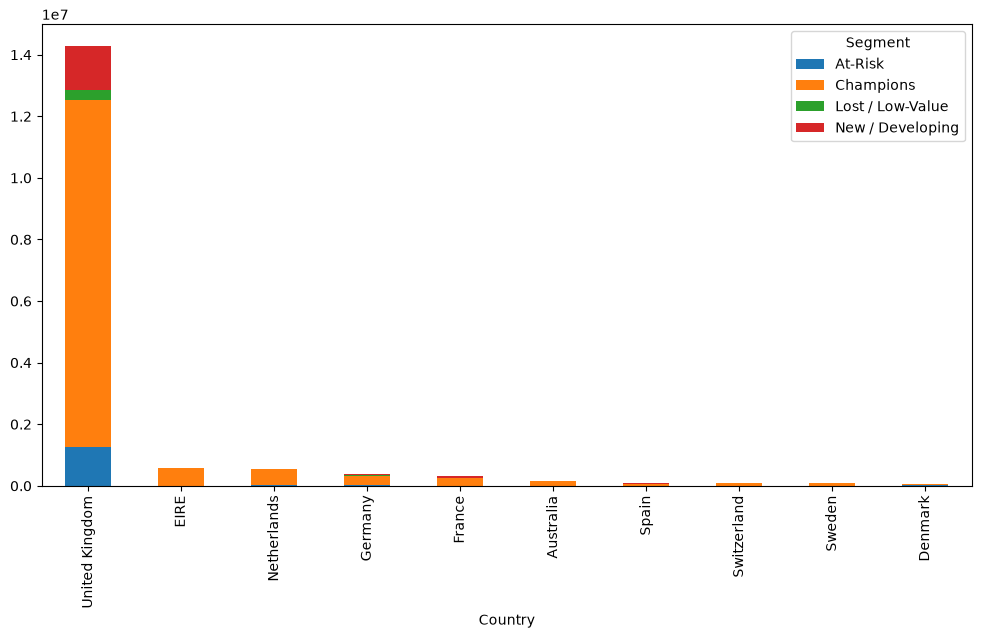

In [44]:
# Segment × Country — which segments dominate which markets
seg_country = customer_df.merge(segmentation_df[['CustomerID','Segment']], on='CustomerID').groupby(['Country','Segment'])['Revenue'].sum().unstack(fill_value=0)

seg_country.loc[seg_country.sum(axis=1).sort_values(ascending=False).head(10).index].plot(
    kind='bar', stacked=True, figsize=(12,6)
)

In [45]:
new_df = customer_df.merge(segmentation_df[['CustomerID','Segment']], on='CustomerID')
champions = new_df[new_df['Segment'] == 'Champions']
champions['IsUK'] = champions['Country'] == 'United Kingdom'
champions_orders = champions.groupby(['CustomerID', 'Invoice', 'IsUK'], as_index=False)['Revenue'].sum()
champions_summary = champions_orders.groupby('IsUK').agg(
    Customers=('CustomerID', 'nunique'),
    Revenue=('Revenue', 'sum'),
    AvgOrderValue=('Revenue', 'mean')
)
champions_summary

,Customers,Revenue,AvgOrderValue
IsUK,,,
False,154,2.373796e+06,985.386629
True,1600,1.128382e+07,468.636121


- UK Monopoly: The vast majority of revenue originates from the UK across all segments. However, the UK also holds almost all of the At-Risk (blue) and Lost / Low-Value (green) accounts.
- International Pure Champions: Key international markets like EIRE, Netherlands, Germany, France, and Australia consist almost entirely of Champions (orange). These international buyers are highly valuable wholesale/trade accounts with virtually no churned or low-value noise.
- This also confirms the EIRE concentration finding from Global EDA - its small, high-value customer base consists almost entirely of Champions-tier wholesale accounts, not broad retail reach.
- Also, the table shows that international champions roughly have 2x more AOV, even though there are far fewer of them.

In [46]:
# Segment × Product — top products per segment
seg_products = customer_df.merge(segmentation_df[['CustomerID','Segment']], on='CustomerID')

for c in sorted(seg_products['Segment'].unique()):
    top5 = (seg_products[seg_products['Segment']==c]
            .groupby('Description')['Revenue'].sum()
            .sort_values(ascending=False).head(5))
    print(f"\n {c} — Top 5 products:")
    print(top5)


 At-Risk — Top 5 products:
Description
MEDIUM CERAMIC TOP STORAGE JAR        77226.10
WHITE HANGING HEART T-LIGHT HOLDER    19098.55
REGENCY CAKESTAND 3 TIER              14494.35
SET/4 WHITE RETRO STORAGE CUBES        9311.95
JUMBO BAG RED RETROSPOT                7594.79
Name: Revenue, dtype: float64

 Champions — Top 5 products:
Description
REGENCY CAKESTAND 3 TIER              243653.70
WHITE HANGING HEART T-LIGHT HOLDER    205487.61
JUMBO BAG RED RETROSPOT               152119.90
ASSORTED COLOUR BIRD ORNAMENT         106531.60
PARTY BUNTING                          85257.88
Name: Revenue, dtype: float64

 Lost / Low-Value — Top 5 products:
Description
WHITE HANGING HEART T-LIGHT HOLDER    4748.75
REGENCY CAKESTAND 3 TIER              4672.20
JUMBO BAG RED RETROSPOT               2835.03
PARTY BUNTING                         2769.25
ANTIQUE SILVER TEA GLASS ENGRAVED     2632.05
Name: Revenue, dtype: float64

 New / Developing — Top 5 products:
Description
PAPER CRAFT , LITTLE BIRD

- Notice that New/Developing cluster is driven overwhelmingly by a single massive anomaly product — PAPER CRAFT , LITTLE BIRDIE (~£168.5k). A single high-volume new buyer likely purchased this item.
- Also, the top product in At-Risk cluster, MEDIUM CERAMIC TOP STORAGE JAR, seems to follow a similar pattern.
- We can check the products in each segment by distinct customer count so that it's less skewed by one big order.

In [47]:
# Top products by DISTINCT CUSTOMER COUNT rather than revenue — less skewed by one big order
for c in sorted(seg_products['Segment'].unique()):
    top5_by_reach = (seg_products[seg_products['Segment']==c]
                      .groupby('Description')['CustomerID'].nunique()
                      .sort_values(ascending=False).head(5))
    print(f"\n{c} — Top 5 products by customer reach:")
    print(top5_by_reach)


At-Risk — Top 5 products by customer reach:
Description
WHITE HANGING HEART T-LIGHT HOLDER    335
REGENCY CAKESTAND 3 TIER              207
BAKING SET 9 PIECE RETROSPOT          201
PACK OF 72 RETROSPOT CAKE CASES       182
ASSORTED COLOUR BIRD ORNAMENT         173
Name: CustomerID, dtype: int64

Champions — Top 5 products by customer reach:
Description
WHITE HANGING HEART T-LIGHT HOLDER    782
REGENCY CAKESTAND 3 TIER              728
PACK OF 72 RETROSPOT CAKE CASES       681
JUMBO BAG RED RETROSPOT               610
LUNCH BAG RED RETROSPOT               573
Name: CustomerID, dtype: int64

Lost / Low-Value — Top 5 products by customer reach:
Description
WHITE HANGING HEART T-LIGHT HOLDER    167
REX CASH+CARRY JUMBO SHOPPER          130
REGENCY CAKESTAND 3 TIER              111
BAKING SET 9 PIECE RETROSPOT          101
ASSORTED COLOUR BIRD ORNAMENT          77
Name: CustomerID, dtype: int64

New / Developing — Top 5 products by customer reach:
Description
BAKING SET 9 PIECE RETROSPOT 

WHITE HANGING HEART T-LIGHT HOLDER and REGENCY CAKESTAND 3 TIER appear in the top 5 for all four segments — these are universal bestsellers, not segment-specific preferences. This is itself a useful finding: these two SKUs need guaranteed stock availability regardless of which customer segment you're marketing to.

- Champions: uniquely favor RETROSPOT-branded bags (Jumbo Bag, Lunch Bag) rather than the baking/kitchenware items every other segment favors. Combined with their enormous average units-per-customer (4,631) and the international-Champions finding, this is consistent with resale/repackaging behavior — i.e., a meaningful share of Champions may be small businesses or market-stall resellers buying bags and gift items in bulk, not end consumers.
- New / Developing: show a distinct seasonal skew — Paper Chain Kit (Christmas) and Bird Ornament both appear only in their top 5. Onboard this segment by cross-selling the core home items popular with Champions.
- At-Risk: The same three items are popular in this segment as well. Target these lapsed customers with a win-back email featuring restocking alerts or discounts specifically for storage, kitchenware, and core decor items (CAKESTAND, T-LIGHT HOLDER).
- Lost / Low-Value: Shares the same top product preferences as Champions (T-LIGHT HOLDER, CAKESTAND), but bought in tiny quantities. One distinct item is the REX CASH+CARRY JUMBO SHOPPER — fits their profile: an infrequent, bulk-lite, one-off purchase pattern rather than a considered repeat relationship. Re-engage them via automated seasonal bulk-buy promotions.

This also confirms the earlier speculation: the previous revenue-weighted "top products" (Paper Craft Little Birdie, Medium Ceramic Storage Jar) don't appear anywhere in this cleaner view — they were single-order artifacts, not real segment preferences.

### Final Segment Scorecard

In [48]:
scorecard = segmentation_df.groupby('Segment').agg(
    Customers=('CustomerID', 'count'),
    Recency_Median=('Recency', 'median'),
    Frequency_Median=('Frequency', 'median'),
    Monetary_Median=('Monetary', 'median'),
    Tenure_Median=('Tenure', 'median'),
    AOV_Median=('AvgOrderValue', 'median'),
    Diversity_Median=('Diversity', 'median'),
).join(
    segmentation_df.groupby('Segment')['Monetary'].sum().rename('TotalRevenue')
)
scorecard['RevenueSharePercent'] = (scorecard['TotalRevenue'] / scorecard['TotalRevenue'].sum() * 100).round(1)
scorecard

,Customers,Recency_Median,Frequency_Median,Monetary_Median,Tenure_Median,AOV_Median,Diversity_Median,TotalRevenue,RevenueSharePercent
Segment,,,,,,,,,
At-Risk,1253,396.0,3.0,818.79,622.0,320.964286,41.0,1.398862e+06,8.2
Champions,1754,29.0,10.0,3589.62,674.0,348.589013,141.0,1.365762e+07,80.0
Lost / Low-Value,1556,360.0,1.0,199.95,414.0,146.350000,12.0,3.483948e+05,2.0
New / Developing,1290,33.0,3.0,828.32,211.5,326.635000,44.0,1.663709e+06,9.7


## Business Recommendations:

| Segment | Size | Revenue Share | Recommended Strategy |
|---|---|---|---|
| **Champions** | 1,754 (30%) | 80% | Prioritise retention and loyalty investment: loyalty programme, early access to new products, premium/VIP treatment. Even small improvements in retention here have outsized revenue impact. |
| **At-Risk** | 1,253 (21%) | 8.2% | Highest-priority win-back target: ~£1.3M of historically-proven revenue is currently at risk of full churn - personalized re-engagement campaigns, targeted offers referencing past purchase history, proactive outreach before full lapse. |
| **New/Developing** | 1,290 (22%) | 9.7% | Nurture toward Champions: onboarding sequences, incentivize a second and third purchase, monitor for early signs of increasing frequency/diversity. |
| **Lost/Low-Value** | 1,556 (26%) | 2.0% | Low-cost, automated marketing only (email/retargeting); do not invest in personalized retention spend here — the expected return is low relative to the At-Risk segment. |

Additional Recommendations:
- Universal bestseller stock priority - T-Light Holder and Regency Cakestand appear across every segment — treat these as core, always-in-stock SKUs regardless of which marketing campaign is running; a stockout here damages every segment simultaneously.
- Champions - The combination of high units purchased per customer, bag-focused purchasing, and international concentration suggests a meaningful chunk of "Champions" may be small resellers, not end consumers. Company could go for B2B-style account management (dedicated contact, negotiated terms, bulk pricing tiers) rather than a typical consumer loyalty program for these chunks of wholesale/reseller accounts.
- Differentiate Champions strategy by geography - International Champions generate ~2x revenue **per customer** versus UK Champions, despite being a much smaller group (154 vs. 1,600), company could go for a dedicated international trade-account strategy distinct from the UK loyalty program.
- Capitalize on seasonal purchases - Since volume and revenue increases toward Christmas-season, design a post-holiday retention sequence specifically timed after Nov/Dec e.g., a January/February win-back nudge so as to retain customers who actively bought during the season.

## Conclusion

This segmentation identifies four behaviorally distinct customer groups — Champions, At-Risk, New/Developing, and Lost/Low-Value — using K-Means clustering (K=4 was selected based on the combination of clustering diagnostics and business interpretability, with hierarchical clustering used as an additional consistency check.) on rank-normalized RFM and supporting behavioral features (Tenure, Average Order Value, Product Diversity).

**Revenue is extremely concentrated.** Champions represent 30% of the customer base but generate 80% of revenue (£13.9M) — a textbook Pareto pattern that should anchor virtually every retention and loyalty decision this business makes. By contrast, Lost/Low-Value customers (26% of the base) contribute just 2.0% of revenue (£348K), confirming that broad, undifferentiated marketing spend across the full customer base would be inefficient.

**At-Risk is the single highest-leverage segment for action.** These 1,253 customers carry a median Tenure of 622 days — nearly matching Champions (674 days) — and a median historical spend of £818, evidence of genuine, proven engagement that has since gone quiet (median Recency of 396 days). With ~£1.3M in historically-demonstrated revenue on the line, this segment offers the clearest return on a targeted win-back campaign: the value is already proven, unlike Lost/Low-Value customers who never showed comparable engagement to begin with.

**Segment identity extends beyond RFM alone.** Segment × geography and segment × product analysis revealed that Champions' behavior — high units per order, bag/packaging-focused purchasing, and outsized international representation — is consistent with a meaningful reseller/wholesale component within this segment, not purely individual retail consumers. This reframes the appropriate strategy for a portion of Champions from consumer loyalty marketing toward B2B-style account management, and suggests UK and international Champions may warrant genuinely different treatment rather than a single unified "VIP" programme.

**Individual account nuance.** A small number of high-value, wholesale-pattern customers (first identified in Global EDA) recur throughout this analysis — appearing as revenue outliers, influencing segment-level product rankings, and anchoring the At-Risk segment's profile. These accounts warrant direct, individual monitoring alongside segment-level strategy, since a single such account can be worth more than dozens of typical customers in the same segment.

**Answering the original business questions:** This phase directly identifies the most valuable customers (Champions), those at risk of churning (At-Risk), who should receive discounts versus loyalty rewards (At-Risk for win-back offers, Champions for premium/loyalty treatment), and how marketing should be personalized (segment-specific product affinities and channel strategy, detailed above).

**Next steps:** This segmentation feeds directly into two remaining phases. CLV modeling will quantify expected *future* value per customer and segment — sharpening the At-Risk versus Lost/Low-Value distinction beyond historical spend alone, and testing whether the reseller hypothesis for Champions holds under a forward-looking value model. Market Basket Analysis will extend the segment × product findings here into actionable cross-sell and bundling recommendations, particularly for the universal bestsellers identified across all four segments.